# TX (Mirror) Scan Analysis — Class-based API

This notebook demonstrates the new `StepData` / `ScanData` / `ScanSet` API
for analysing CARCARÁ-X mirror-scan HDF5 data.

**Before starting**, set `workdir` and `pattern` in the second cell to
point at your HDF5 files.

In [1]:
from caxscripts.scananalysis import DataSet
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import siriuspy

In [8]:
siriuspy.__file__

'/opt/mamba_files/mamba/envs/sirius/lib/python3.9/site-packages/siriuspy/__init__.py'

In [2]:
# ── CONFIGURE THESE ──────────────────────────────────────────────────
workdir = "/home/amici/data/testing_data/2026-03-19"
pattern = r"mirror_tx_pass[0-1][0-3]+"
# pattern = r"slit"
# ─────────────────────────────────────────────────────────────────────

tx_passes = DataSet(workdir, pattern)
tx_passes

<DataSet: 4 × mirror, var=mirror.tx>

## 1. Explore available data

Each scan pass is a `ScanData` object.  Use `.describe()` to see its
observables (beam properties + metadata keys).

In [3]:
for scan in tx_passes.scans:
    scan.describe_scan()
    print()

Scan #0  [mirror]
  variable : mirror.tx
  steps    : 13
  observables (12): centroid, fwhm, intensity, centroid_x, centroid_y, fwhm_x, fwhm_y, intensity_peak, intensity_mask, intensity_fwhm_norm, mirror.photocollector, step

Scan #1  [mirror]
  variable : mirror.tx
  steps    : 13
  observables (12): centroid, fwhm, intensity, centroid_x, centroid_y, fwhm_x, fwhm_y, intensity_peak, intensity_mask, intensity_fwhm_norm, mirror.photocollector, step

Scan #2  [mirror]
  variable : mirror.tx
  steps    : 13
  observables (12): centroid, fwhm, intensity, centroid_x, centroid_y, fwhm_x, fwhm_y, intensity_peak, intensity_mask, intensity_fwhm_norm, mirror.photocollector, step

Scan #3  [mirror]
  variable : mirror.tx
  steps    : 13
  observables (12): centroid, fwhm, intensity, centroid_x, centroid_y, fwhm_x, fwhm_y, intensity_peak, intensity_mask, intensity_fwhm_norm, mirror.photocollector, step



## 2. Plot observables vs. scanned variable

Multi-component observables (`centroid`, `fwhm`, `intensity`) expand
into separate subplots per component.  Scalar metadata keys (e.g. `ry`,
`cs_rz`) work directly — no registration needed.

In [4]:
scan0 = tx_passes.scans[0]
print(scan0)

<DataScan #0: mirror, 13 steps>


In [8]:
scan0.scan_animation(observables='centroid')

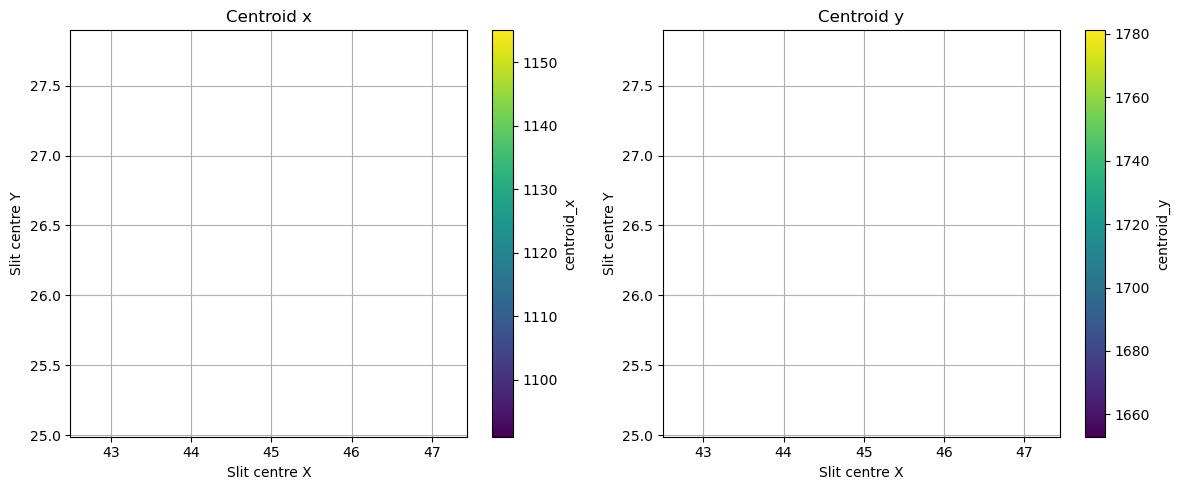

In [6]:
scan = tx_passes.scans[0]
scan.observables = ['centroid']
fig, axs = scan.plot_observables()

In [ ]:
# Restrict to a subset of steps
scan.step_range = (2, 18)  # steps 2 … 17
fig, axs = scan.plot_observables(observables=['centroid', 'intensity'])

In [ ]:
# Reset range for subsequent cells
scan.step_range = None

## 3. Per-scan statistics

Extract mean / standard deviation for any observable on a single pass.

In [ ]:
print("Centroid X mean:",     scan.mean_value('centroid_x'))
print("Centroid X std.dev:",  scan.std_deviation('centroid_x'))
print("FWHM X mean:",         scan.mean_value('fwhm_x'))
print("FWHM Y mean:",         scan.mean_value('fwhm_y'))

## 4. Multi-pass statistics

`ScanSet.statistics()` returns mean / median / std across all passes.

In [ ]:
stats = tx_passes.statistics('centroid_x')
for k, v in stats.items():
    print(f"{k}:  shape={v.shape},  values={v}")

In [ ]:
fig, (axm, axd) = plt.subplots(1, 2, figsize=(15, 5))

idx = stats['xval']
axm.errorbar(idx, stats['mean'], yerr=stats['std_dev'],
             fmt='o-', label='mean')
axm.plot(idx, stats['median'], 's-', label='median', color='red')
axm.set_xlabel('Tx (mm)')
axm.set_ylabel('Centroid X (px)')
axm.set_title('Centroid X — multi-pass statistics')
axm.legend()
axm.grid(True)

axd.plot(idx, stats['std_dev'], 'o-', color='green')
axd.set_xlabel('Tx (mm)')
axd.set_ylabel('Std. Dev. (px)')
axd.set_title('Centroid X — standard deviation')
axd.grid(True)
plt.tight_layout()

## 5. Superimposed traces and correlation

Overlay the same observable from every pass on a single axes.

In [ ]:
fig, ax = tx_passes.plot_superimposed('intensity_peak')

In [ ]:
corr = tx_passes.correlation_matrix('centroid_x')
print("Pairwise correlation matrix (centroid_x):")
print(corr)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='viridis', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xlabel('Scan index')
ax.set_ylabel('Scan index')
ax.set_title('centroid_x correlation')
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha='center', va='center',
                color='w' if abs(corr[i, j]) > 0.5 else 'k')
plt.tight_layout()

## 6. Centroid-vs-motor drift

Look at how a motor position and the centroid X change across passes.

In [ ]:
fig, axs = tx_passes.centroid_delta_plot('mirror.tx',
                                          step_start=0, step_end=-1)

## 7. Centroid linear fit

Fit a line to the centroid-vs-Tx trace and estimate a rotation angle.

In [ ]:
pixsize = 0.48  # um/px

scan = tx_passes.scans[0]
xv, (cx, cy) = scan.resolve_observable('centroid')
xv = xv * 1000  # mm -> um  (adjust units as needed)

idx = xv[1:-1]
ax, bx = np.polyfit(idx, cx[1:-1] * pixsize, 1)
ay, by = np.polyfit(idx, cy[1:-1] * pixsize, 1)

fig, (axx, axy) = plt.subplots(1, 2, figsize=(14, 5))

axx.plot(xv, cx * pixsize, 'o-', label='Centroid X')
axx.plot(idx, ax * idx + bx, 'r--', label=f'fit (slope={ax:.4f})')
axx.set_xlabel('Tx (um)')
axx.set_ylabel('Centroid X (um)')
axx.set_title('Centroid X vs Tx')
axx.legend()
axx.grid(True)

axy.plot(xv, cy * pixsize, 'o-', label='Centroid Y')
axy.plot(idx, ay * idx + by, 'r--', label=f'fit (slope={ay:.4f})')
axy.set_xlabel('Tx (um)')
axy.set_ylabel('Centroid Y (um)')
axy.set_title('Centroid Y vs Tx')
axy.legend()
axy.grid(True)

phi = np.arctan(ay / 1000)  # approximate rotation
print(f"Rotation angle (from Y slope): {phi * 1e3:.3f} urad")
plt.tight_layout()

## 8. Beam image + centroid animation

Animate all steps for a single pass: beam image on top, centroid / fwhm
trace below with a marker following the current step.

In [ ]:
scan.observables = ['centroid']
anim = scan.scan_animation(filename=None, fps=2)  # inline

In [ ]:
# Save to file instead
# scan.scan_animation(filename='tx_pass00.gif', fps=2, save_fmt='gif')

## 9. Inspect a single step

Look at a specific step's image, beam properties, and metadata.

In [ ]:
step = scan.steps[5]  # sixth step
print(step)
print()
print("Beam properties:")
for k, v in step.beam_properties.items():
    if k != 'intensity':
        print(f"  {k:>20s} = {v}")
print(f"  {'intensity':>20s} = {step.beam_properties['intensity']}")

In [ ]:
fig, ax = step.plot_image()
ax.set_title(f"Step {step.step_index} — centroid {step.beam_properties['centroid']}")

## 10. Compare DVF A1 vs B1 images

When both detectors are available, view them side by side for any step.

In [ ]:
step = scan.steps[0]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax1.imshow(step.image, cmap='viridis')
plt.colorbar(im1, ax=ax1)
ax1.set_title('DVF B1 (primary)')

if step.image_secondary is not None:
    im2 = ax2.imshow(step.image_secondary, cmap='viridis')
    plt.colorbar(im2, ax=ax2)
    ax2.set_title('DVF A1 (secondary)')
else:
    ax2.text(0.5, 0.5, 'No secondary image',
             ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()

In [ ]:
print("Metadata keys for this step:")
for k, v in sorted(step.metadata.items()):
    print(f"  {k:30s} = {v}")